# 🌾 Nettoyage des Datasets Agricoles

**Stratégie d'unités** : on garde **une seule unité par variable** pour éviter la redondance.
- Variables d'intensité → **kg/ha** (comparable entre pays)
- Température → **°C**
- Précipitations → **mm**
- Superficies → **1000 ha** ou **%**

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = 'data/raw'
CLEAN_DIR = 'data/cleaned'
os.makedirs(CLEAN_DIR, exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
sns.set_palette('Set2')

In [36]:
def clean_faostat_fr(filepath, extra_cols_to_drop=None):
    """Nettoyage commun pour les datasets FAOSTAT en français."""
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(filepath, encoding=enc)
            break
        except (UnicodeDecodeError, UnicodeError):
            continue
    
    print(f'Shape initial : {df.shape}')
    
    cols_to_drop = ['Code zone', 'Code zone (M49)', 'Code Produit', 
                    'Code Élément', 'Code année', 'Symbole', 'Note']
    if extra_cols_to_drop:
        cols_to_drop += extra_cols_to_drop
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    rename_map = {'Zone': 'Pays', 'Année': 'Annee'}
    df = df.rename(columns={k:v for k,v in rename_map.items() if k in df.columns})
    return df


def clean_faostat_en(filepath, extra_cols_to_drop=None):
    """Nettoyage commun pour les datasets FAOSTAT en anglais."""
    df = pd.read_csv(filepath, encoding='utf-8')
    print(f'Shape initial : {df.shape}')
    
    cols_to_drop = ['Area Code', 'Area Code (M49)', 'Item Code', 
                    'Element Code', 'Year Code', 'Flag', 'Note']
    if extra_cols_to_drop:
        cols_to_drop += extra_cols_to_drop
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)
    
    df = df.rename(columns={'Area': 'Pays', 'Item': 'Produit', 'Element': 'Element',
                            'Year': 'Annee', 'Unit': 'Unite', 'Value': 'Valeur'})
    return df


def standard_cleaning(df, name, value_col='Valeur'):
    """Nettoyage standard : NaN, doublons, types."""
    # Valeurs manquantes
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'Valeurs manquantes :')
        for col, n in missing.items():
            print(f'  {col}: {n} ({100*n/len(df):.1f}%)')
    else:
        print('Aucune valeur manquante')
    
    before = len(df)
    df = df.dropna(subset=[value_col])
    if before - len(df) > 0:
        print(f'Lignes supprimées (Valeur NaN) : {before - len(df)}')
    
    before = len(df)
    df = df.drop_duplicates()
    if before - len(df) > 0:
        print(f'Doublons supprimés : {before - len(df)}')
    
    if 'Annee' in df.columns:
        df['Annee'] = df['Annee'].astype(int)
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    
    return df


def detect_outliers(df, value_col='Valeur', group_cols=None):
    """Détecte les outliers via IQR (sans les supprimer)."""
    if group_cols and all(c in df.columns for c in group_cols):
        def flag(g):
            Q1, Q3 = g[value_col].quantile(0.25), g[value_col].quantile(0.75)
            IQR = Q3 - Q1
            return (g[value_col] < Q1 - 1.5*IQR) | (g[value_col] > Q3 + 1.5*IQR)
        mask = df.groupby(group_cols, group_keys=False).apply(flag)
    else:
        Q1, Q3 = df[value_col].quantile(0.25), df[value_col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[value_col] < Q1 - 1.5*IQR) | (df[value_col] > Q3 + 1.5*IQR)
    
    n = mask.sum()
    print(f'Outliers (IQR) : {n} ({100*n/len(df):.1f}%) — non supprimés')
    return mask


def summary(df, name):
    """Résumé final."""
    print(f'\n{"="*50}')
    print(f'RÉSUMÉ : {name}')
    print(f'{"="*50}')
    print(f'Shape : {df.shape}')
    print(f'Colonnes : {list(df.columns)}')
    if 'Pays' in df.columns:
        print(f'Pays : {df["Pays"].nunique()}')
    if 'Annee' in df.columns:
        print(f'Années : {df["Annee"].min()} - {df["Annee"].max()}')
    if 'Valeur' in df.columns:
        print(f'Valeur : min={df["Valeur"].min():.2f}, max={df["Valeur"].max():.2f}, '
              f'mean={df["Valeur"].mean():.2f}')
    print()

---
## 1️⃣ Bilan Nutritif des Sols
Flux de nutriments du sol. **On garde uniquement les valeurs en kg/ha** (par unité de surface).

In [37]:
df_bns = clean_faostat_fr(f'{RAW_DIR}/Bilan_Nutritif_Sols.csv')

# ✅ FILTRE UNITÉ : garder uniquement kg/ha
print(f'\nUnités disponibles : {df_bns["Unité"].unique()}')
df_bns = df_bns[df_bns['Unité'] == 'kg/ha'].copy()
print(f'Après filtre kg/ha : {df_bns.shape}')

# On peut supprimer la colonne Unité (elle est constante maintenant)
# et la colonne Élément (une seule valeur restante)
df_bns = df_bns.drop(columns=['Unité', 'Élément'])

df_bns = standard_cleaning(df_bns, 'Bilan Nutritif Sols')
df_bns.head()

Shape initial : (196030, 12)

Unités disponibles : <StringArray>
['tonnes', 'kg/ha']
Length: 2, dtype: str
Après filtre kg/ha : (96793, 6)
Aucune valeur manquante


,Pays,Produit,Annee,Valeur
58,Afghanistan,Engrais synthétiques,1961,0.1299
59,Afghanistan,Engrais synthétiques,1962,0.1289
60,Afghanistan,Engrais synthétiques,1963,0.1280
61,Afghanistan,Engrais synthétiques,1964,0.1270
62,Afghanistan,Engrais synthétiques,1965,0.1270


Outliers (IQR) : 6214 (6.4%) — non supprimés


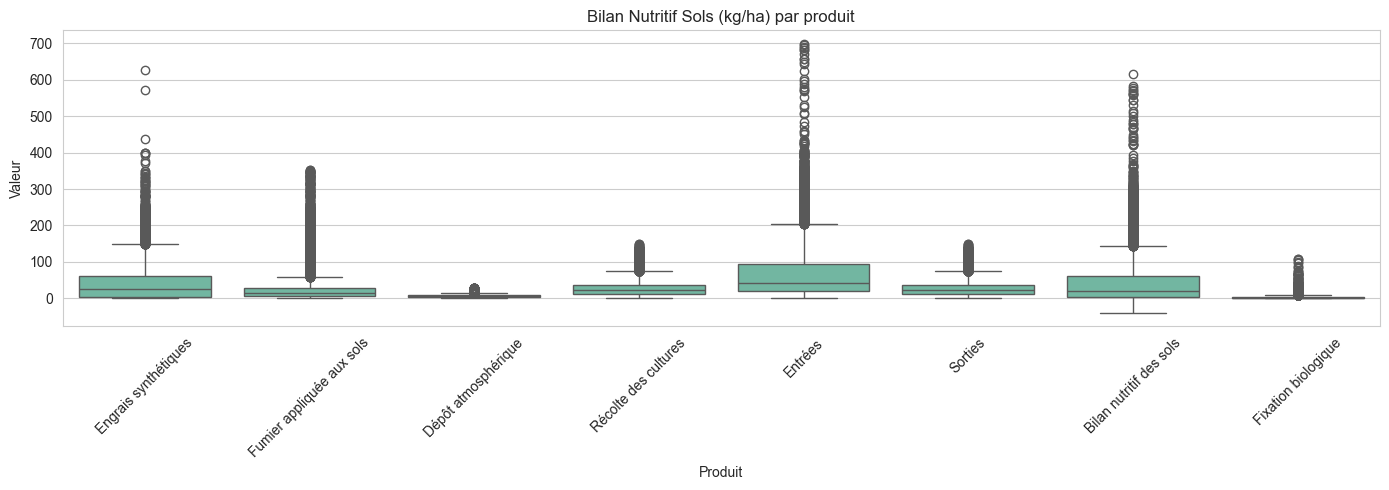

In [38]:
detect_outliers(df_bns, group_cols=['Produit'])

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_bns, x='Produit', y='Valeur', ax=ax)
ax.set_title('Bilan Nutritif Sols (kg/ha) par produit')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [39]:
summary(df_bns, 'Bilan Nutritif Sols')
print('Produits :', list(df_bns['Produit'].unique()))


RÉSUMÉ : Bilan Nutritif Sols
Shape : (96793, 4)
Colonnes : ['Pays', 'Produit', 'Annee', 'Valeur']
Pays : 241
Années : 1961 - 2018
Valeur : min=-39.74, max=698.79, mean=30.56

Produits : ['Engrais synthétiques', 'Fumier appliquée aux sols', 'Dépôt atmosphérique', 'Récolte des cultures', 'Entrées', 'Sorties', 'Bilan nutritif des sols', 'Fixation biologique']


---
## 2️⃣ Bilan Nutritif Terres Cultivées
Bilan NPK. **On garde kg/ha** (quantités par surface) **et %** (efficacité d'utilisation).

In [40]:
df_bntc = clean_faostat_fr(f'{RAW_DIR}/Bilan_Nutritif_Terres_Cultivés.csv')

# ✅ FILTRE UNITÉ : garder kg/ha et %
print(f'\nUnités disponibles : {df_bntc["Unité"].unique()}')
df_bntc = df_bntc[df_bntc['Unité'].isin(['kg/ha', '%'])].copy()
print(f'Après filtre kg/ha + % : {df_bntc.shape}')

df_bntc = standard_cleaning(df_bntc, 'Bilan Nutritif Terres Cultivées')
df_bntc.head()

Shape initial : (827796, 13)

Unités disponibles : <StringArray>
['tonnes', 'kg/ha', '%']
Length: 3, dtype: str
Après filtre kg/ha + % : (434148, 6)
Aucune valeur manquante


,Pays,Produit,Élément,Annee,Unité,Valeur
63,Afghanistan,Engrais minéraux,Terres cultivées azote par unité de surface,1961,kg/ha,0.1290
64,Afghanistan,Engrais minéraux,Terres cultivées azote par unité de surface,1962,kg/ha,0.1282
65,Afghanistan,Engrais minéraux,Terres cultivées azote par unité de surface,1963,kg/ha,0.1274
66,Afghanistan,Engrais minéraux,Terres cultivées azote par unité de surface,1964,kg/ha,0.0696
67,Afghanistan,Engrais minéraux,Terres cultivées azote par unité de surface,1965,kg/ha,0.0695


In [41]:
# Aperçu des éléments gardés
print('Éléments restants :')
for e in sorted(df_bntc['Élément'].unique()):
    n = len(df_bntc[df_bntc['Élément']==e])
    u = df_bntc[df_bntc['Élément']==e]['Unité'].unique()
    print(f'  {e} ({list(u)}) — {n} lignes')

Éléments restants :
  Efficacité d'utilisation de l'azote des terres cultivées (['%']) — 13500 lignes
  Efficacité d'utilisation du phosphore des terres cultivées (['%']) — 13500 lignes
  Efficacité d'utilisation du potassium sur les terres cultivées (['%']) — 13500 lignes
  Terres cultivées azote par unité de surface (['kg/ha']) — 161273 lignes
  Terres cultivées phosphore par unité de surface (['kg/ha']) — 116216 lignes
  Terres cultivées potassium par unité de surface (['kg/ha']) — 116159 lignes


Outliers (IQR) : 28675 (6.6%) — non supprimés


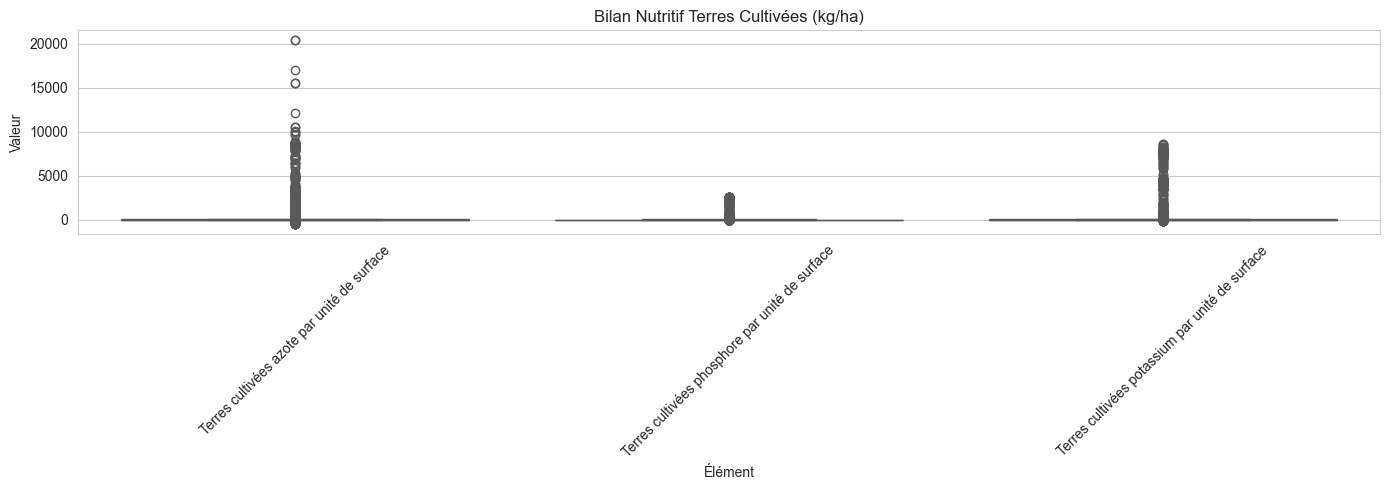

In [42]:
detect_outliers(df_bntc, group_cols=['Produit', 'Élément'])

fig, ax = plt.subplots(figsize=(14, 5))
subset = df_bntc[df_bntc['Unité'] == 'kg/ha']
if len(subset) > 0:
    sns.boxplot(data=subset, x='Élément', y='Valeur', ax=ax)
    ax.set_title('Bilan Nutritif Terres Cultivées (kg/ha)')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [43]:
summary(df_bntc, 'Bilan Nutritif Terres Cultivées')


RÉSUMÉ : Bilan Nutritif Terres Cultivées
Shape : (434148, 6)
Colonnes : ['Pays', 'Produit', 'Élément', 'Annee', 'Unité', 'Valeur']
Pays : 233
Années : 1961 - 2023
Valeur : min=-555.52, max=20476.34, mean=36.28



---
## 3️⃣ Variation de Température
Déjà en **°C** uniquement. On garde la variation + écart-type.

In [44]:
df_temp = clean_faostat_fr(f'{RAW_DIR}/Env_Variation_Temp.csv')

# Déjà une seule unité (°C), on peut la supprimer
print(f'Unités : {df_temp["Unité"].unique()}')
df_temp = df_temp.drop(columns=['Unité'])

df_temp = standard_cleaning(df_temp, 'Variation Température')
df_temp.head()

Shape initial : (572356, 12)
Unités : <StringArray>
['°C']
Length: 1, dtype: str
Valeurs manquantes :
  Valeur: 24152 (4.2%)
Lignes supprimées (Valeur NaN) : 24152


,Pays,Code Mois,Mois,Élément,Annee,Valeur
0,Afghanistan,7001,Janvier,Variation de température,1961,0.792
1,Afghanistan,7001,Janvier,Variation de température,1962,0.066
2,Afghanistan,7001,Janvier,Variation de température,1963,2.700
3,Afghanistan,7001,Janvier,Variation de température,1964,-5.267
4,Afghanistan,7001,Janvier,Variation de température,1965,1.839


Outliers (IQR) : 17610 (3.2%) — non supprimés


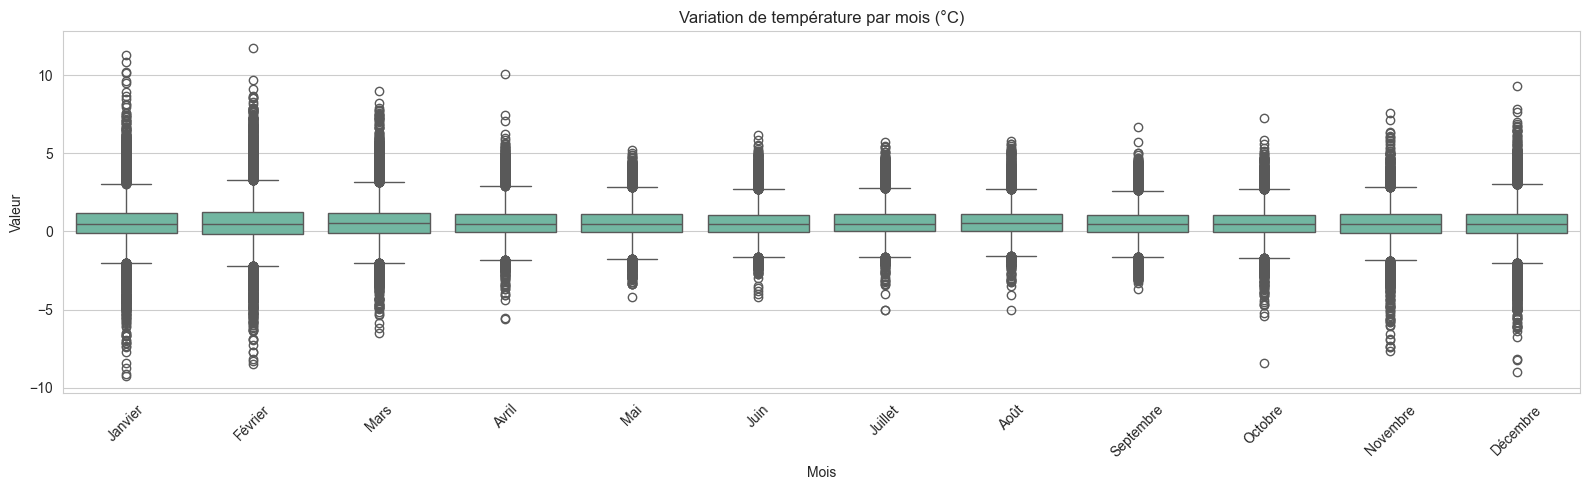

In [45]:
detect_outliers(df_temp, group_cols=['Mois', 'Élément'])

months_order = ['Janvier','Février','Mars','Avril','Mai','Juin',
                'Juillet','Août','Septembre','Octobre','Novembre','Décembre']
fig, ax = plt.subplots(figsize=(16, 5))
monthly = df_temp[df_temp['Mois'].isin(months_order) & (df_temp['Élément'].str.contains('Variation'))]
sns.boxplot(data=monthly, x='Mois', y='Valeur', order=months_order, ax=ax)
ax.set_title('Variation de température par mois (°C)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [46]:
summary(df_temp, 'Variation Température')


RÉSUMÉ : Variation Température
Shape : (548204, 6)
Colonnes : ['Pays', 'Code Mois', 'Mois', 'Élément', 'Annee', 'Valeur']
Pays : 284
Années : 1961 - 2024
Valeur : min=-9.27, max=11.75, mean=0.64



---
## 4️⃣ Intrants / Utilisation des Terres
On garde les **superficies (1000 ha)** et les **parts (%)**. On exclut ha/personne et USD_PPP/ha.

In [47]:
df_terres = clean_faostat_fr(f'{RAW_DIR}/Intrants_Terres_Utilisation.csv')

# ✅ FILTRE UNITÉ : garder 1000 ha et %
print(f'\nUnités disponibles : {df_terres["Unité"].unique()}')
df_terres = df_terres[df_terres['Unité'].isin(['1000 ha', '%'])].copy()
print(f'Après filtre : {df_terres.shape}')

df_terres = standard_cleaning(df_terres, 'Intrants / Utilisation Terres')
df_terres.head()

Shape initial : (413211, 13)

Unités disponibles : <StringArray>
['1000 ha', '%', 'USD_PPP/ha', 'ha/personne', 'millions de tonnes']
Length: 5, dtype: str
Après filtre : (374594, 6)
Aucune valeur manquante


,Pays,Produit,Élément,Annee,Unité,Valeur
0,Afghanistan,Superficie du pays,Superficie,1961,1000 ha,65286.0
1,Afghanistan,Superficie du pays,Superficie,1962,1000 ha,65286.0
2,Afghanistan,Superficie du pays,Superficie,1963,1000 ha,65286.0
3,Afghanistan,Superficie du pays,Superficie,1964,1000 ha,65286.0
4,Afghanistan,Superficie du pays,Superficie,1965,1000 ha,65286.0


In [48]:
print('Produits disponibles :')
for p in sorted(df_terres['Produit'].unique()):
    n = len(df_terres[df_terres['Produit']==p])
    print(f'  - {p} ({n} lignes)')

Produits disponibles :
  - Agriculture (15804 lignes)
  - Autres terres (9069 lignes)
  - Bâtiments et cours de ferme (270 lignes)
  - Cultures permanentes (29114 lignes)
  - Cultures temporaires (5928 lignes)
  - Eaux continent. utilisées pour aquacult. ou bassins de stabulat. (149 lignes)
  - Eaux continent. utilisées pour la pêche de capture (57 lignes)
  - Eaux continentales (11835 lignes)
  - Eaux côtières (372 lignes)
  - Eaux côtières utilisées pour aquacult. ou bassins de stabulat. (139 lignes)
  - Eaux côtières utilisées pour la pêche de capture (50 lignes)
  - Forêt naturellement régénérée (18002 lignes)
  - Forêt plantée (15616 lignes)
  - Forêt primaire (7177 lignes)
  - Jachères (temporaires) (5927 lignes)
  - Prairies et de pâturages temporaires (5879 lignes)
  - Prairies et pâturages permanents (44058 lignes)
  - Prairies et pâturages permanents cultivés (1026 lignes)
  - Prairies et pâturages permanents naturels (1128 lignes)
  - Superficie des terres (16228 lignes)
  -

Outliers (IQR) : 72872 (19.5%) — non supprimés


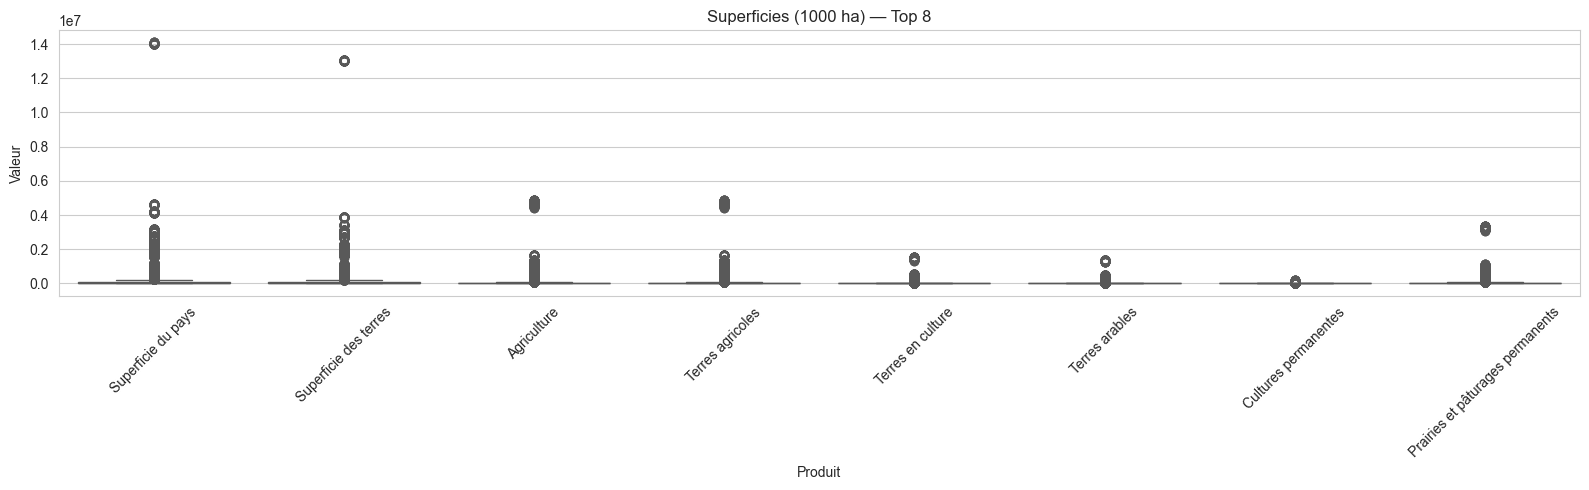

In [49]:
detect_outliers(df_terres, group_cols=['Produit'])

top_prods = df_terres[df_terres['Unité']=='1000 ha'].groupby('Produit').size().nlargest(8).index
fig, ax = plt.subplots(figsize=(16, 5))
subset = df_terres[(df_terres['Produit'].isin(top_prods)) & (df_terres['Unité'] == '1000 ha')]
if len(subset) > 0:
    sns.boxplot(data=subset, x='Produit', y='Valeur', ax=ax)
    ax.set_title('Superficies (1000 ha) — Top 8')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [50]:
summary(df_terres, 'Intrants / Utilisation Terres')


RÉSUMÉ : Intrants / Utilisation Terres
Shape : (374594, 6)
Colonnes : ['Pays', 'Produit', 'Élément', 'Annee', 'Unité', 'Valeur']
Pays : 284
Années : 1961 - 2025
Valeur : min=0.00, max=14095798.83, mean=46429.99



---
## 5️⃣ Production Cultures & Produits Animaux
**Dataset cible.** On sépare cultures végétales (Production en tonnes, Rendement en kg/ha, Superficie en ha)
des produits animaux (Tête, kg/Tête, etc.).

⚠️ Fichier volumineux (~558 Mo).

In [51]:
print('⏳ Chargement du fichier Production (558 Mo)...')
df_prod = clean_faostat_fr(f'{RAW_DIR}/ProdCulture_ProduitsAnimaux.csv', 
                           extra_cols_to_drop=['Code Produit (CPC)'])
print('✅ Chargement terminé')

print(f'\nÉléments disponibles :')
for e in sorted(df_prod['Élément'].unique()):
    units = df_prod[df_prod['Élément']==e]['Unité'].unique()
    print(f'  {e} -> {list(units)}')

⏳ Chargement du fichier Production (558 Mo)...
Shape initial : (4209110, 14)
✅ Chargement terminé

Éléments disponibles :
  Animaux Producteurs/Abattus -> ['Tête', '1000 têtes']
  Animaux laitiers -> ['Tête']
  Pondeuses -> ['1000 têtes']
  Production -> ['tonnes', '1000 No']
  Rendement -> ['kg/ha', 'No/An']
  Rendement/Poids Carcasse -> ['kg/Tête', 'g/Tête']
  Réserves -> ['Tête', '1000 têtes', 'No']
  Superficie récoltée -> ['ha']


In [52]:
# ✅ SÉPARATION : Cultures végétales vs Produits animaux
# Cultures = Production (tonnes) + Rendement (kg/ha) + Superficie récoltée (ha)
mask_cultures = (
    (df_prod['Élément'].isin(['Production', 'Rendement', 'Superficie récoltée'])) &
    (df_prod['Unité'].isin(['tonnes', 'kg/ha', 'ha']))
)

df_cultures = df_prod[mask_cultures].copy()
df_animaux = df_prod[~mask_cultures].copy()

print(f'Cultures végétales : {len(df_cultures)} lignes, {df_cultures["Produit"].nunique()} produits')
print(f'Produits animaux : {len(df_animaux)} lignes, {df_animaux["Produit"].nunique()} produits')

# Nettoyage
df_cultures = standard_cleaning(df_cultures, 'Cultures végétales')
df_animaux = standard_cleaning(df_animaux, 'Produits animaux')

Cultures végétales : 3341945 lignes, 280 produits
Produits animaux : 867165 lignes, 69 produits
Valeurs manquantes :
  Valeur: 90490 (2.7%)
Lignes supprimées (Valeur NaN) : 90490
Valeurs manquantes :
  Valeur: 3865 (0.4%)
Lignes supprimées (Valeur NaN) : 3865


In [53]:
print(f'Exemples de cultures ({df_cultures["Produit"].nunique()} au total) :')
for p in sorted(df_cultures['Produit'].unique())[:30]:
    print(f'  - {p}')
if df_cultures['Produit'].nunique() > 30:
    print(f'  ... et {df_cultures["Produit"].nunique()-30} autres')

Exemples de cultures (280 au total) :
  - Abaca, chanvre de manille, brut
  - Abats comestibles de chameaux et autres camélidés, frais, réfrigérés ou congelés
  - Abats comestibles de chevaux et autres équidés, frais, réfrigérés ou congelés
  - Abats, comestibles, bovins, frais, réfrigérés ou congelés
  - Abats, comestibles, buffle, frais, réfrigérés ou congelés
  - Abats, comestibles, caprins, frais, réfrigérés ou congelés
  - Abats, comestibles, ovins, frais, réfrigérés ou congelés
  - Abats, comestibles, suides, frais, réfrigérés ou congelés
  - Abricots
  - Agrumes, total
  - Ail frais
  - Alpiste
  - Amandes non décortiquées
  - Ananas
  - Anis, badiane, coriandre, cumin, carvi, fenouil et baies de genièvre, crus
  - Arachides non décortiquées
  - Artichauts
  - Asperges
  - Aubergines
  - Autre fruit à noyau n.a.c.
  - Autre fruit à pépins n.a.c.
  - Autres baies et fruits du genre caccinium, n.a.c.
  - Autres espèces cultivées stimulantes, à épices et aromatiques, n.c.a.
  - Aut

Outliers (IQR) : 478102 (14.7%) — non supprimés


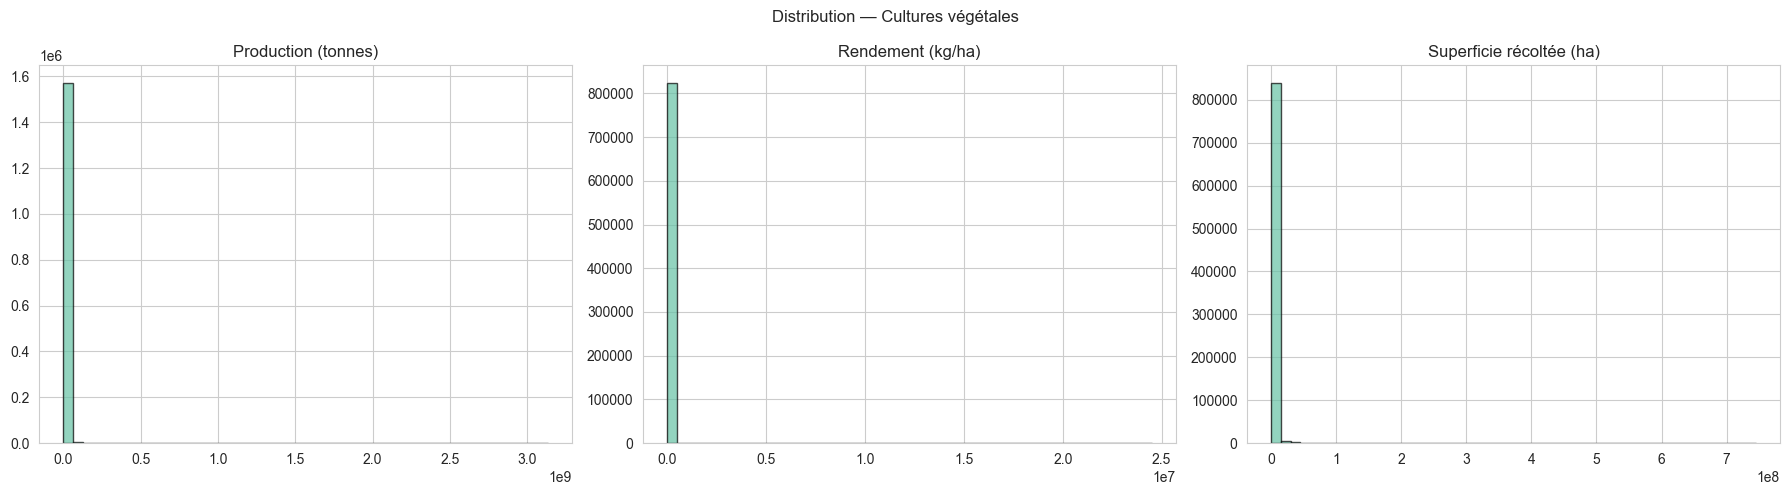

In [54]:
detect_outliers(df_cultures, group_cols=['Élément'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, elem in enumerate(['Production', 'Rendement', 'Superficie récoltée']):
    subset = df_cultures[df_cultures['Élément'] == elem]
    if len(subset) > 0:
        axes[i].hist(subset['Valeur'], bins=50, edgecolor='black', alpha=0.7)
        u = subset['Unité'].iloc[0]
        axes[i].set_title(f'{elem} ({u})')
plt.suptitle('Distribution — Cultures végétales')
plt.tight_layout()
plt.show()

In [55]:
summary(df_cultures, 'Production — Cultures végétales')
summary(df_animaux, 'Production — Produits animaux')


RÉSUMÉ : Production — Cultures végétales
Shape : (3251455, 6)
Colonnes : ['Pays', 'Produit', 'Élément', 'Annee', 'Unité', 'Valeur']
Pays : 244
Années : 1961 - 2024
Valeur : min=0.00, max=3133222740.92, mean=1474752.11


RÉSUMÉ : Production — Produits animaux
Shape : (863300, 6)
Colonnes : ['Pays', 'Produit', 'Élément', 'Annee', 'Unité', 'Valeur']
Pays : 242
Années : 1961 - 2024
Valeur : min=0.00, max=2550115176.00, mean=6281969.02



---
## 6️⃣ Fertilizers by Nutrient
Engrais NPK. **On garde uniquement "Use per area of cropland" (kg/ha)**.

In [56]:
df_fert = clean_faostat_en(f'{RAW_DIR}/Inputs_FertilizersNutrient.csv')

# ✅ FILTRE : garder uniquement l'usage par hectare
print(f'\nÉléments disponibles :')
for e in sorted(df_fert['Element'].unique()):
    print(f'  - {e}')

df_fert = df_fert[df_fert['Element'] == 'Use per area of cropland'].copy()
print(f'\nAprès filtre "Use per area of cropland" : {df_fert.shape}')

# Supprimer les colonnes devenues constantes
df_fert = df_fert.drop(columns=['Element', 'Unite'])

df_fert = standard_cleaning(df_fert, 'Fertilizers by Nutrient')
df_fert.head()

Shape initial : (241859, 13)

Éléments disponibles :
  - Agricultural Use
  - Export quantity
  - Import quantity
  - Production
  - Use per area of cropland
  - Use per capita
  - Use per value of agricultural production

Après filtre "Use per area of cropland" : (36849, 6)
Aucune valeur manquante


,Pays,Produit,Annee,Valeur
222,Afghanistan,Nutrient nitrogen N (total),1961,0.13
223,Afghanistan,Nutrient nitrogen N (total),1962,0.13
224,Afghanistan,Nutrient nitrogen N (total),1963,0.13
225,Afghanistan,Nutrient nitrogen N (total),1964,0.13
226,Afghanistan,Nutrient nitrogen N (total),1965,0.13


Outliers (IQR) : 2799 (7.6%) — non supprimés


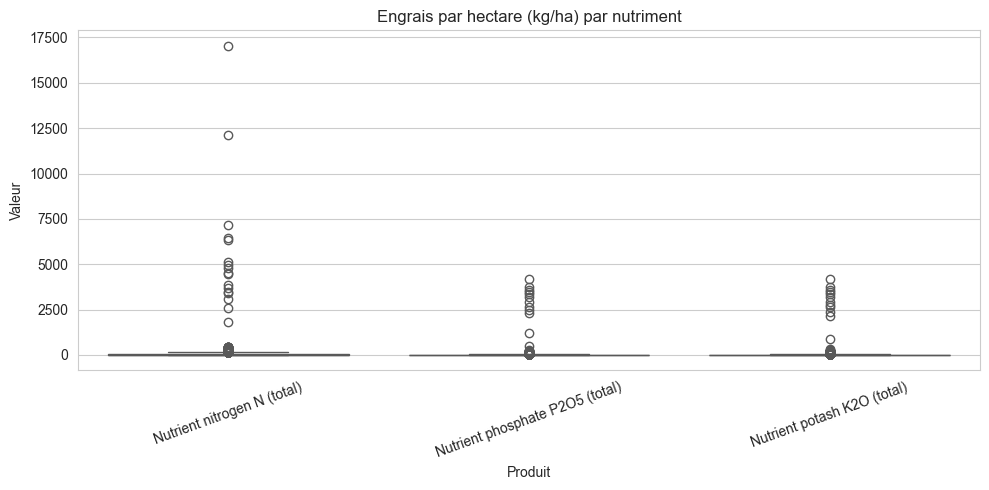

In [57]:
detect_outliers(df_fert, group_cols=['Produit'])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_fert, x='Produit', y='Valeur', ax=ax)
ax.set_title('Engrais par hectare (kg/ha) par nutriment')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [58]:
summary(df_fert, 'Fertilizers by Nutrient')


RÉSUMÉ : Fertilizers by Nutrient
Shape : (36849, 4)
Colonnes : ['Pays', 'Produit', 'Annee', 'Valeur']
Pays : 242
Années : 1961 - 2023
Valeur : min=-0.13, max=17038.07, mean=32.85



---
## 7️⃣ Mean Temperature (World Bank)
Température moyenne en **°C**. Format World Bank → on ne garde que pays, année, valeur.

In [59]:
df_mean_temp = pd.read_csv(f'{RAW_DIR}/Mean_Temperature.csv', encoding='utf-8')
print(f'Shape initial : {df_mean_temp.shape} ({len(df_mean_temp.columns)} colonnes)')

# ✅ Garder uniquement les colonnes utiles
df_mean_temp = df_mean_temp[['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_mean_temp = df_mean_temp.rename(columns={
    'REF_AREA': 'Code_Pays', 'REF_AREA_LABEL': 'Pays',
    'TIME_PERIOD': 'Annee', 'OBS_VALUE': 'Valeur'
})
print(f'Après sélection : {df_mean_temp.shape}')

df_mean_temp = standard_cleaning(df_mean_temp, 'Mean Temperature')
df_mean_temp.head()

Shape initial : (17612, 41) (41 colonnes)
Après sélection : (17612, 4)
Aucune valeur manquante


,Code_Pays,Pays,Annee,Valeur
0,IRL,Ireland,1950,9.52
1,IRL,Ireland,1951,9.30
2,IRL,Ireland,1952,9.48
3,IRL,Ireland,1953,10.07
4,IRL,Ireland,1954,9.50


Outliers (IQR) : 111 (0.6%) — non supprimés


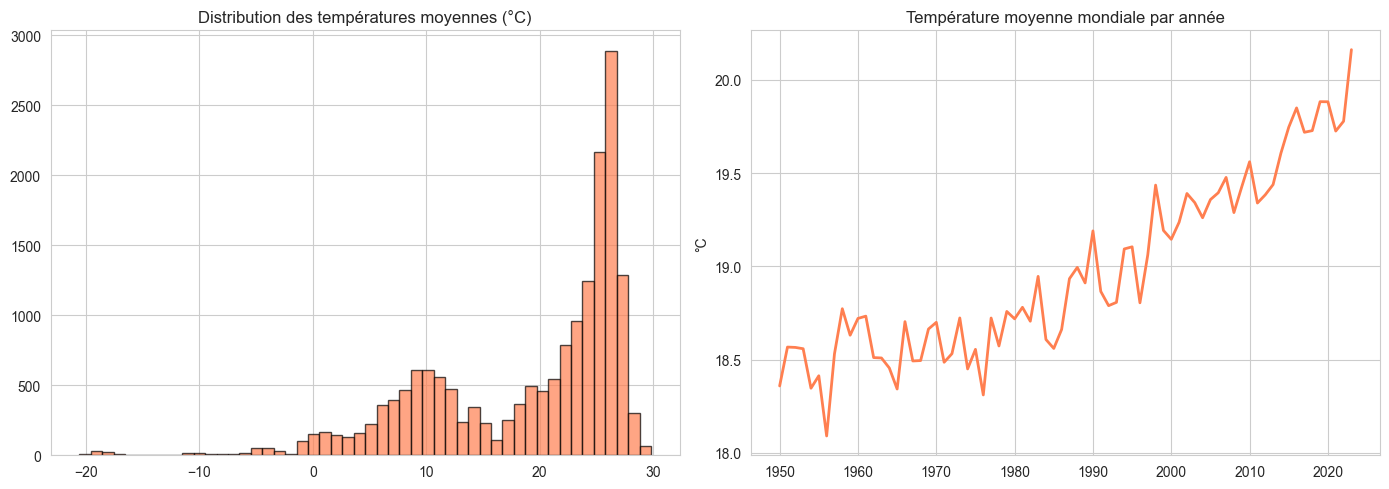

In [60]:
detect_outliers(df_mean_temp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_mean_temp['Valeur'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_title('Distribution des températures moyennes (°C)')

yearly_avg = df_mean_temp.groupby('Annee')['Valeur'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, color='coral', linewidth=2)
axes[1].set_title('Température moyenne mondiale par année')
axes[1].set_ylabel('°C')
plt.tight_layout()
plt.show()

In [61]:
summary(df_mean_temp, 'Mean Temperature')


RÉSUMÉ : Mean Temperature
Shape : (17612, 4)
Colonnes : ['Code_Pays', 'Pays', 'Annee', 'Valeur']
Pays : 238
Années : 1950 - 2023
Valeur : min=-20.58, max=29.82, mean=18.97



---
## 8️⃣ Précipitations (World Bank)
Précipitations en **mm**. Même format World Bank.

In [62]:
df_precip = pd.read_csv(f'{RAW_DIR}/Precipitations_mm.csv', encoding='utf-8')
print(f'Shape initial : {df_precip.shape}')

df_precip = df_precip[['REF_AREA', 'REF_AREA_LABEL', 'TIME_PERIOD', 'OBS_VALUE']].copy()
df_precip = df_precip.rename(columns={
    'REF_AREA': 'Code_Pays', 'REF_AREA_LABEL': 'Pays',
    'TIME_PERIOD': 'Annee', 'OBS_VALUE': 'Valeur'
})
print(f'Après sélection : {df_precip.shape}')

df_precip = standard_cleaning(df_precip, 'Précipitations')
df_precip.head()

Shape initial : (17612, 41)
Après sélection : (17612, 4)
Aucune valeur manquante


,Code_Pays,Pays,Annee,Valeur
0,IOT,British Indian Ocean Territory (UK),1950,1736.26
1,IOT,British Indian Ocean Territory (UK),1951,2048.54
2,IOT,British Indian Ocean Territory (UK),1952,1712.86
3,IOT,British Indian Ocean Territory (UK),1953,2286.52
4,IOT,British Indian Ocean Territory (UK),1954,2290.69


Outliers (IQR) : 750 (4.3%) — non supprimés


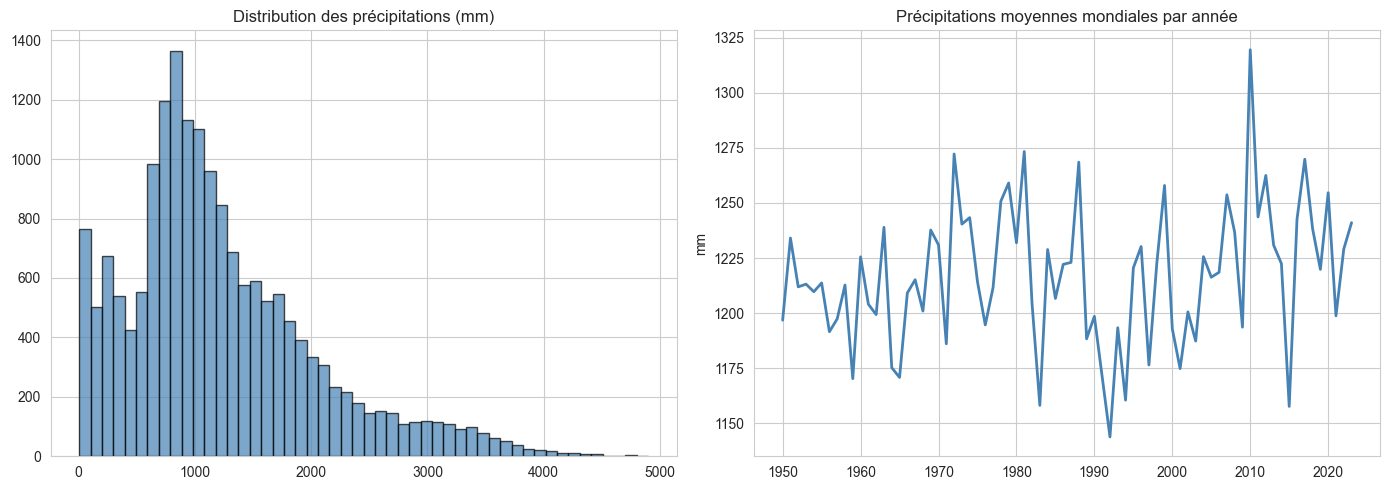

In [63]:
detect_outliers(df_precip)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_precip['Valeur'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution des précipitations (mm)')

yearly_avg = df_precip.groupby('Annee')['Valeur'].mean()
axes[1].plot(yearly_avg.index, yearly_avg.values, color='steelblue', linewidth=2)
axes[1].set_title('Précipitations moyennes mondiales par année')
axes[1].set_ylabel('mm')
plt.tight_layout()
plt.show()

In [64]:
summary(df_precip, 'Précipitations')


RÉSUMÉ : Précipitations
Shape : (17612, 4)
Colonnes : ['Code_Pays', 'Pays', 'Annee', 'Valeur']
Pays : 238
Années : 1950 - 2023
Valeur : min=4.90, max=4897.40, mean=1216.80



---
## 9️⃣ Pesticides
**On garde uniquement "Use per area of cropland" (kg/ha)**.

In [65]:
df_pest = clean_faostat_en(f'{RAW_DIR}/Pesticides_Inputs.csv')

# ✅ FILTRE : garder uniquement l'usage par hectare
print(f'\nÉléments disponibles :')
for e in sorted(df_pest['Element'].unique()):
    print(f'  - {e}')

df_pest = df_pest[df_pest['Element'] == 'Use per area of cropland'].copy()
print(f'\nAprès filtre : {df_pest.shape}')

df_pest = df_pest.drop(columns=['Element', 'Unite'])

df_pest = standard_cleaning(df_pest, 'Pesticides')
df_pest.head()

Shape initial : (103622, 13)

Éléments disponibles :
  - Agricultural Use
  - Use per area of cropland
  - Use per capita
  - Use per value of agricultural production

Après filtre : (7805, 6)
Aucune valeur manquante


,Pays,Produit,Annee,Valeur
34,Albania,Pesticides (total),1990,0.17
35,Albania,Pesticides (total),1991,0.17
36,Albania,Pesticides (total),1992,0.17
37,Albania,Pesticides (total),1993,0.17
38,Albania,Pesticides (total),1994,0.29


In [66]:
# Types de pesticides disponibles
print('Types de pesticides :')
for p in sorted(df_pest['Produit'].unique()):
    n = len(df_pest[df_pest['Produit']==p])
    print(f'  - {p} ({n} lignes)')

Types de pesticides :
  - Pesticides (total) (7805 lignes)


In [67]:
def detect_outliers(df, value_col='Valeur', group_cols=None):
    """Détecte les outliers via IQR (sans les supprimer)."""
    if group_cols and all(c in df.columns for c in group_cols):
        # Utilisation de .transform, beaucoup plus stable et rapide que .apply !
        Q1 = df.groupby(group_cols)[value_col].transform(lambda x: x.quantile(0.25))
        Q3 = df.groupby(group_cols)[value_col].transform(lambda x: x.quantile(0.75))
        IQR = Q3 - Q1
        mask = (df[value_col] < Q1 - 1.5*IQR) | (df[value_col] > Q3 + 1.5*IQR)
    else:
        Q1, Q3 = df[value_col].quantile(0.25), df[value_col].quantile(0.75)
        IQR = Q3 - Q1
        mask = (df[value_col] < Q1 - 1.5*IQR) | (df[value_col] > Q3 + 1.5*IQR)
    
    # On s'assure de récupérer un entier standard (et pas un objet pandas)
    n = int(np.sum(mask.to_numpy()))
    
    print(f'Outliers (IQR) : {n} ({100*n/len(df):.1f}%) — non supprimés')
    return mask


In [68]:
summary(df_pest, 'Pesticides')


RÉSUMÉ : Pesticides
Shape : (7805, 4)
Colonnes : ['Pays', 'Produit', 'Annee', 'Valeur']
Pays : 240
Années : 1990 - 2023
Valeur : min=0.00, max=38.77, mean=4.03



---
## 💾 Export des datasets nettoyés

In [69]:
datasets_to_export = {
    'bilan_nutritif_sols.csv': df_bns,
    'bilan_nutritif_terres_cultivees.csv': df_bntc,
    'variation_temperature.csv': df_temp,
    'intrants_utilisation_terres.csv': df_terres,
    'production_cultures.csv': df_cultures,
    'production_animaux.csv': df_animaux,
    'fertilizers_nutrient.csv': df_fert,
    'mean_temperature.csv': df_mean_temp,
    'precipitations.csv': df_precip,
    'pesticides.csv': df_pest,
}

print('Export des datasets nettoyés :')
for filename, df in datasets_to_export.items():
    filepath = f'{CLEAN_DIR}/{filename}'
    df.to_csv(filepath, index=False, encoding='utf-8')
    size_mb = os.path.getsize(filepath) / (1024*1024)
    print(f'  ✅ {filename} — {df.shape[0]} lignes, {df.shape[1]} colonnes ({size_mb:.1f} Mo)')

print(f'\nTous les datasets nettoyés exportés dans {CLEAN_DIR}/')

Export des datasets nettoyés :
  ✅ bilan_nutritif_sols.csv — 96793 lignes, 4 colonnes (4.2 Mo)
  ✅ bilan_nutritif_terres_cultivees.csv — 434148 lignes, 6 colonnes (40.7 Mo)
  ✅ variation_temperature.csv — 548204 lignes, 6 colonnes (31.6 Mo)
  ✅ intrants_utilisation_terres.csv — 374594 lignes, 6 colonnes (26.2 Mo)
  ✅ production_cultures.csv — 3251455 lignes, 6 colonnes (223.5 Mo)
  ✅ production_animaux.csv — 863300 lignes, 6 colonnes (71.6 Mo)
  ✅ fertilizers_nutrient.csv — 36849 lignes, 4 colonnes (1.9 Mo)
  ✅ mean_temperature.csv — 17612 lignes, 4 colonnes (0.5 Mo)
  ✅ precipitations.csv — 17612 lignes, 4 colonnes (0.5 Mo)
  ✅ pesticides.csv — 7805 lignes, 4 colonnes (0.3 Mo)

Tous les datasets nettoyés exportés dans data/cleaned/


---
## 📊 Récapitulatif

| Dataset | Unité | Rôle |
|---------|-------|------|
| `production_cultures.csv` | tonnes, kg/ha, ha | **CIBLE** (Rendement) |
| `bilan_nutritif_sols.csv` | kg/ha | Santé du sol |
| `bilan_nutritif_terres_cultivees.csv` | kg/ha, % | NPK détaillé |
| `variation_temperature.csv` | °C | Climat (anomalies) |
| `intrants_utilisation_terres.csv` | 1000 ha, % | Utilisation des terres |
| `fertilizers_nutrient.csv` | kg/ha | Engrais N/P/K |
| `mean_temperature.csv` | °C | Température absolue |
| `precipitations.csv` | mm | Pluie |
| `pesticides.csv` | kg/ha | Pesticides |
| `production_animaux.csv` | varié | Production animale |